# Componente Práctico 3 — Modelo Estrella, Visualizaciones y Carga a AWS
UIDE



## Introducción

En esta práctica se completa la etapa final del proceso ETL sobre los tres datasets de ciberseguridad trabajados en las semanas anteriores. El flujo de trabajo de esta semana comprende tres grandes bloques:

1. **Modelo de Estrella**: creación de dimensiones y tabla de hechos que estructuran el Data Warehouse analítico.
2. **Visualizaciones**: tres gráficos que permiten interpretar los datos transformados y apoyar la toma de decisiones.
3. **Carga a AWS**: exportación de los DataFrames a CSV, carga al bucket de Amazon S3 y posterior carga al clúster de Amazon Redshift Serverless.

Los datasets utilizados son los mismos procesados en la Práctica Semana 2:
- `df_threats_sel` — incidentes de ciberseguridad (PostgreSQL)
- `df_cib_eda_sel` — índices globales de ciberseguridad por país (CSV)
- `df_usenet_sel` — usuarios de internet por país (CSV)

---

## SECCIÓN 0: Importación de Librerías y Carga de Datos Transformados

Se importan todas las librerías necesarias para esta práctica:

- **`pandas`** / **`numpy`**: manipulación de datos y operaciones numéricas.
- **`matplotlib`** / **`seaborn`**: generación de visualizaciones estáticas.
- **`boto3`**: SDK oficial de AWS para Python. Permite interactuar con S3 y otros servicios de AWS desde el código.
- **`redshift_connector`**: driver de Python para conectarse directamente a Amazon Redshift y ejecutar consultas SQL.
- **`dotenv`** / **`os`**: carga segura de credenciales AWS desde variables de entorno.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import boto3
import redshift_connector
import os
from dotenv import load_dotenv

# Cargar variables de entorno (credenciales AWS y Redshift)
load_dotenv()

# Estilo visual global para todas las gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


### 0.1 — Recarga de los DataFrames transformados (Semana 2)

Se recargan los tres datasets que fueron limpiados y transformados en la Práctica Semana 2.
Esto asegura que el punto de partida de esta práctica sea exactamente el estado final
de la etapa de transformación ya validada.

In [4]:
DATA_PATH = os.getenv('DATA_PATH', 'data/')

# ── Fuente 1: Incidentes de ciberseguridad ───────────────────────────────────
# Dataset proveniente de PostgreSQL, transformado en Semana 2
# Si no está disponible la BD, se carga desde el CSV exportado en Semana 2
try:
    from sqlalchemy import create_engine
    DB_USER = os.getenv("POSTGRES_USER")
    DB_PASSWORD = os.getenv("POSTGRES_PASSWORD")
    DB_NAME = os.getenv("POSTGRES_DB")
    DB_HOST = os.getenv("POSTGRES_HOST")
    engine = create_engine(
        f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}'
    )
    df_threats = pd.read_sql('SELECT * FROM cybersecurity_threats', engine)
    print(f'✅ df_threats cargado desde PostgreSQL: {df_threats.shape}')
except Exception as e:
    print(f'⚠️  PostgreSQL no disponible: {e}')
    df_threats = pd.read_csv(f'{DATA_PATH}cybersecurity_threats.csv')
    print(f'✅ df_threats cargado desde CSV: {df_threats.shape}')

# ── Fuente 2: Índices de ciberseguridad por país ─────────────────────────────
df_cib_eda = pd.read_csv(f'{DATA_PATH}Cyber_security.csv')
print(f'✅ df_cib_eda cargado: {df_cib_eda.shape}')

# ── Fuente 3: Usuarios de internet por país ──────────────────────────────────
df_usenet = pd.read_csv(f'{DATA_PATH}internet_users_by_country_cleaned.csv')
print(f'✅ df_usenet cargado:  {df_usenet.shape}')

✅ df_threats cargado desde PostgreSQL: (3000, 11)
✅ df_cib_eda cargado: (192, 6)
✅ df_usenet cargado:  (215, 7)


### 0.2 — Aplicar transformaciones de Semana 2

Se re-aplican las funciones de limpieza y selección de columnas definidas en la Práctica Semana 2
para obtener los DataFrames en su estado final transformado, listos para construir el modelo estrella.

In [5]:
# ── Función reutilizable: normalizar nombres de columnas ─────────────────────
def limpiar_nombres_columnas(df):
    df.columns = (
        df.columns
        .str.strip().str.lower()
        .str.replace(' ', '_', regex=False)
        .str.replace(r'[()$]', '', regex=True)
        .str.replace(r'_+', '_', regex=True)
        .str.strip('_')
    )
    return df

# ── Función reutilizable: normalizar texto categórico ────────────────────────
def normalizar_texto(df, col):
    df[col] = df[col].astype(str).str.strip().str.title()
    return df

# ── Aplicar a df_threats ─────────────────────────────────────────────────────
df_threats = limpiar_nombres_columnas(df_threats)
df_threats = df_threats.drop_duplicates()
for col in ['attack_type', 'target_industry', 'severity_level', 'country']:
    if col in df_threats.columns:
        df_threats = normalizar_texto(df_threats, col)

# Detectar automáticamente columnas de pérdida financiera y tiempo de resolución
col_financiera = [c for c in df_threats.columns if 'loss' in c or 'financial' in c]
col_resolucion = [c for c in df_threats.columns if 'resolution' in c or 'time' in c]

print('Columna financiera detectada:', col_financiera)
print('Columna resolución detectada:', col_resolucion)

# Reconstruir df_threats_sel incluyendo todas las columnas relevantes
cols_threats = ['country', 'attack_type', 'target_industry', 'severity_level'] \
               + col_financiera + col_resolucion

df_threats_sel = df_threats[[c for c in cols_threats if c in df_threats.columns]].copy()

# ── Aplicar a df_cib_eda ─────────────────────────────────────────────────────
df_cib_eda = limpiar_nombres_columnas(df_cib_eda)
df_cib_eda = df_cib_eda.drop_duplicates()
df_cib_eda['region'] = df_cib_eda['region'].str.replace('Asia-Pasific','Asia-Pacific', regex=False)
df_cib_eda = normalizar_texto(df_cib_eda, 'country')
df_cib_eda = normalizar_texto(df_cib_eda, 'region')
for col in ['gci','ncsi','ddl','cei']:
    if col in df_cib_eda.columns:
        med_global = df_cib_eda[col].median()
        df_cib_eda[col] = df_cib_eda.groupby('region')[col].transform(
            lambda x: x.fillna(x.median())).fillna(med_global)
df_cib_eda_sel = df_cib_eda[['country','region','gci','ncsi','cei','ddl']].copy()

# ── Aplicar a df_usenet ──────────────────────────────────────────────────────
df_usenet = limpiar_nombres_columnas(df_usenet)
df_usenet.rename(columns={'country_or_area': 'country'}, inplace=True)
df_usenet = df_usenet.drop_duplicates()
for col in ['country','region']:
    df_usenet = normalizar_texto(df_usenet, col)
df_usenet_sel = df_usenet[['country','region','internet_users',
                            'percentage_internet_users','population_2021']].copy()

print('\n✅ Transformaciones aplicadas')
print(f'   df_threats_sel : {df_threats_sel.shape}')
print(f'   Columnas       : {df_threats_sel.columns.tolist()}')
print(f'   df_cib_eda_sel : {df_cib_eda_sel.shape}')
print(f'   df_usenet_sel  : {df_usenet_sel.shape}')

✅ Transformaciones aplicadas
   df_threats_sel : (3000, 4)
   df_cib_eda_sel : (192, 6)
   df_usenet_sel  : (215, 5)


---
## SECCIÓN 1: Creación del Modelo de Estrella

### ¿Qué es un Modelo de Estrella?

El **modelo de estrella** (Star Schema) es la estructura más utilizada en Data Warehouses.
Se compone de:
- Una **tabla de hechos** (Fact Table): contiene las métricas cuantitativas y las claves foráneas
  que apuntan a las tablas de dimensión.
- **Tablas de dimensión** (Dimension Tables): describen el contexto de cada hecho
  (quién, qué, dónde, cuándo).

### Diseño del modelo para el proyecto de Ciberseguridad

```
                    ┌─────────────────┐
                    │  dim_pais       │
                    │  id_pais (PK)   │
                    │  country        │
                    │  region         │
                    └────────┬────────┘
                             │
┌──────────────────┐         │        ┌──────────────────────┐
│  dim_ataque      │         │        │  dim_ciberseguridad  │
│  id_ataque (PK)  ├─────────┤        │  id_cib (PK)         │
│  attack_type     │    ┌────┴────┐   │  gci                 │
│  severity_level  │    │  FACT   │───┤  ncsi                │
└──────────────────┘    │ tabla   │   │  cei                 │
                        │hechos   │   │  ddl                 │
┌──────────────────┐    │         │   └──────────────────────┘
│  dim_industria   ├────┤         │
│  id_industria(PK)│    └────┬────┘
│  target_industry │         │
└──────────────────┘         │
                    ┌────────┴────────┐
                    │  dim_internet   │
                    │  id_net (PK)    │
                    │  internet_users │
                    │  pct_users      │
                    │  population     │
                    └─────────────────┘
```

### 1.1 — Función genérica para crear dimensiones

Se define una función que recibe un DataFrame, extrae las columnas indicadas,
elimina duplicados y genera una clave primaria numérica secuencial.
Esta función es reutilizable para crear cualquier dimensión del modelo.

In [6]:
def crear_dimension(df, columnas, nombre_id):
    # Filtrar columnas existentes para evitar errores si el dataset varía
    cols_ok = [c for c in columnas if c in df.columns]

    # Extraer valores únicos de las columnas seleccionadas
    dim = df[cols_ok].drop_duplicates().reset_index(drop=True)

    # Insertar clave primaria secuencial como primera columna
    # range(1, n+1) garantiza que el ID comience en 1, no en 0
    dim.insert(0, nombre_id, range(1, len(dim) + 1))

    return dim

print('✅ Función crear_dimension() definida')

✅ Función crear_dimension() definida


### 1.2 — Creación de las dimensiones del modelo

Se crean las cinco dimensiones del modelo de estrella usando la función `crear_dimension()`.
Cada dimensión encapsula un aspecto del contexto de los incidentes de ciberseguridad.

In [19]:
# ── DIMENSIÓN 1: País ────────────────────────────────────────────────────────
# Contiene el nombre del país y su región geográfica.
# Es la dimensión central que conecta las tres fuentes de datos.
dim_pais = crear_dimension(
    df=df_cib_eda_sel,
    columnas=['country', 'region'],
    nombre_id='id_pais'
)
print(f'dim_pais          : {dim_pais.shape} → {dim_pais.columns.tolist()}')


# ── DIMENSIÓN 2: Tipo de Ataque ──────────────────────────────────────────────
# Se verifica explícitamente qué columnas existen antes de crear la dimensión
cols_ataque = [c for c in ['attack_type', 'severity_level'] if c in df_threats_sel.columns]
dim_ataque = crear_dimension(
    df=df_threats_sel,
    columnas=cols_ataque,
    nombre_id='id_ataque'
)
print(f'dim_ataque        : {dim_ataque.shape} → {dim_ataque.columns.tolist()}')

# ── DIMENSIÓN 3: Industria Objetivo ─────────────────────────────────────────
# Identifica el sector económico que fue blanco del ataque.
# Permite segmentar el análisis por industria afectada.
dim_industria = crear_dimension(
    df=df_threats_sel,
    columnas=['target_industry'],
    nombre_id='id_industria'
)
print(f'dim_industria     : {dim_industria.shape} → {dim_industria.columns.tolist()}')

# ── DIMENSIÓN 4: Índices de Ciberseguridad ───────────────────────────────────
# Contiene los cuatro índices de madurez en ciberseguridad por país.
# Permite contextualizar cada incidente con el nivel de preparación del país.
dim_ciberseguridad = crear_dimension(
    df=df_cib_eda_sel,
    columnas=['country', 'gci', 'ncsi', 'cei', 'ddl'],
    nombre_id='id_cib'
)
print(f'dim_ciberseguridad: {dim_ciberseguridad.shape} → {dim_ciberseguridad.columns.tolist()}')

# ── DIMENSIÓN 5: Internet por País ───────────────────────────────────────────
# Contiene métricas de penetración de internet por país.
# Permite correlacionar la conectividad digital con la incidencia de ataques.
dim_internet = crear_dimension(
    df=df_usenet_sel,
    columnas=['country', 'internet_users', 'percentage_internet_users', 'population_2021'],
    nombre_id='id_net'
)
print(f'dim_internet      : {dim_internet.shape} → {dim_internet.columns.tolist()}')

print('\n✅ Las 5 dimensiones creadas correctamente')

dim_pais          : (192, 3) → ['id_pais', 'country', 'region']
dim_ataque        : (6, 2) → ['id_ataque', 'attack_type']
dim_industria     : (7, 2) → ['id_industria', 'target_industry']
dim_ciberseguridad: (192, 6) → ['id_cib', 'country', 'gci', 'ncsi', 'cei', 'ddl']
dim_internet      : (215, 5) → ['id_net', 'country', 'internet_users', 'percentage_internet_users', 'population_2021']

✅ Las 5 dimensiones creadas correctamente


### 1.3 — Creación de la Tabla de Hechos

La tabla de hechos es el núcleo del modelo de estrella. Contiene:
- **Claves foráneas (FK)**: referencias a cada dimensión (`id_pais`, `id_ataque`, `id_industria`, `id_cib`, `id_net`).
- **Métricas**: los valores cuantitativos que se analizarán (`financial_loss_in_million`, `incident_resolution_time_in_hours`).

El proceso de construcción es:
1. Partir de `df_threats_sel` como base (un registro por incidente).
2. Hacer joins con cada dimensión para reemplazar los valores descriptivos por sus IDs.
3. Conservar solo las claves foráneas y las métricas.

In [13]:
# Paso 1: Partir de df_threats_sel como base de la tabla de hechos
fact_table = df_threats_sel.copy()

# Paso 2: Incorporar id_pais
fact_table = fact_table.merge(
    dim_pais[['id_pais', 'country']],
    on='country',
    how='left'
)

# Paso 3: Incorporar id_ataque — merge solo por columnas que existen en dim_ataque
cols_merge_ataque = [c for c in dim_ataque.columns if c != 'id_ataque']
fact_table = fact_table.merge(
    dim_ataque,
    on=cols_merge_ataque,
    how='left'
)

# Paso 4: Incorporar id_industria
fact_table = fact_table.merge(
    dim_industria[['id_industria', 'target_industry']],
    on='target_industry',
    how='left'
)

# Paso 5: Incorporar id_cib
fact_table = fact_table.merge(
    dim_ciberseguridad[['id_cib', 'country']],
    on='country',
    how='left'
)

# Paso 6: Incorporar id_net
fact_table = fact_table.merge(
    dim_internet[['id_net', 'country']],
    on='country',
    how='left'
)

# Paso 7: Clave primaria de la tabla de hechos
fact_table.insert(0, 'id_hecho', range(1, len(fact_table) + 1))

# Paso 8: Seleccionar solo claves foráneas y métricas
columnas_fact = [
    'id_hecho', 'id_pais', 'id_ataque', 'id_industria',
    'id_cib', 'id_net',
    'financial_loss_in_million',
    'incident_resolution_time_in_hours'
]
fact_table = fact_table[[c for c in columnas_fact if c in fact_table.columns]]

print('TABLA DE HECHOS creada:')
print(f'  Dimensiones  : {fact_table.shape}')
print(f'  Columnas     : {fact_table.columns.tolist()}')
print(f'  Nulos totales: {fact_table.isnull().sum().sum()}')
fact_table.head(10)

TABLA DE HECHOS creada:
  Dimensiones  : (3000, 7)
  Columnas     : ['id_hecho', 'id_pais', 'id_ataque', 'id_industria', 'id_cib', 'id_net', 'incident_resolution_time_in_hours']
  Nulos totales: 1824


,id_hecho,id_pais,id_ataque,id_industria,id_cib,id_net,incident_resolution_time_in_hours
0,1,36.0,1,1,36.0,1.0,63
1,2,36.0,2,2,36.0,1.0,71
2,3,76.0,3,3,76.0,2.0,20
3,4,NaN,2,4,NaN,NaN,7
4,5,64.0,3,3,64.0,14.0,68
5,6,64.0,3,2,64.0,14.0,25
6,7,64.0,4,4,64.0,14.0,34
7,8,60.0,5,5,60.0,19.0,66
8,9,76.0,3,6,76.0,2.0,47
9,10,NaN,4,7,NaN,NaN,58


### 1.4 — Resumen del Modelo de Estrella

Se imprime un resumen con las dimensiones y métricas del modelo para verificar
que la estructura es coherente antes de proceder a las visualizaciones.

In [21]:
tablas_modelo = {
    'fact_table (Hechos)'  : fact_table,
    'dim_pais'             : dim_pais,
    'dim_ataque'           : dim_ataque,
    'dim_industria'        : dim_industria,
    'dim_ciberseguridad'   : dim_ciberseguridad,
    'dim_internet'         : dim_internet,
}

print('═' * 55)
print(f'{"Tabla":<25} {"Filas":>8} {"Columnas":>10}')
print('═' * 55)
for nombre, df in tablas_modelo.items():
    print(f'{nombre:<25} {df.shape[0]:>8} {df.shape[1]:>10}')
print('═' * 55)
print('\n✅ Modelo de estrella completo y validado')

═══════════════════════════════════════════════════════
Tabla                        Filas   Columnas
═══════════════════════════════════════════════════════
fact_table (Hechos)           3000          7
dim_pais                       192          3
dim_ataque                       6          2
dim_industria                    7          2
dim_ciberseguridad             192          6
dim_internet                   215          5
═══════════════════════════════════════════════════════

✅ Modelo de estrella completo y validado


---
## SECCIÓN 2: Visualizaciones de Datos

Se generan tres visualizaciones que permiten analizar los datos del modelo de estrella
y apoyar la toma de decisiones en materia de ciberseguridad.

Cada gráfico responde una pregunta analítica concreta:
1. ¿Cuáles industrias generan mayores pérdidas financieras por incidentes?
2. ¿Existe relación entre el índice de madurez en ciberseguridad (GCI) de un país y su exposición (CEI)?
3. ¿Qué tipos de ataque predominan en el dataset y cuál es su distribución por severidad?

### Visualización 1 — Pérdida Financiera Media por Industria Objetivo

**Pregunta**: ¿Qué sectores económicos sufren las mayores pérdidas financieras
promedio por incidente de ciberseguridad?

Se usa un gráfico de barras horizontales ordenadas de mayor a menor pérdida.
Este tipo de gráfico es ideal para comparar categorías cuando los nombres son largos.

Industrias únicas: 7
      target_industry  incident_resolution_time_in_hours
0             Banking                          35.737079
1          Healthcare                          35.806527
2           Education                          35.906921
3                  It                          36.169456
4  Telecommunications                          37.062035
5              Retail                          37.219858
6          Government                          37.593052


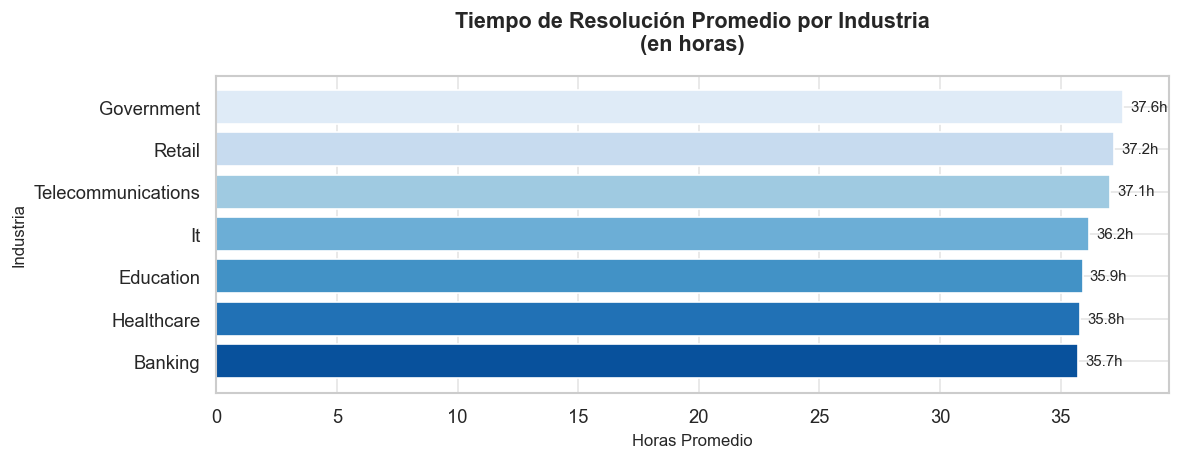

✅ Visualización 1 generada


In [25]:
# Visualización 1 — Tiempo de Resolución Promedio por Industria Objetivo

# Paso 1: calcular el promedio agrupado correctamente
df_viz1 = (
    fact_table[['id_industria', 'incident_resolution_time_in_hours']]
    .merge(dim_industria[['id_industria', 'target_industry']], on='id_industria', how='left')
    .dropna(subset=['target_industry', 'incident_resolution_time_in_hours'])
    .groupby('target_industry', as_index=False)['incident_resolution_time_in_hours']
    .mean()
    .sort_values('incident_resolution_time_in_hours', ascending=True)
    .reset_index(drop=True)
)

# Verificar que tiene pocas filas (una por industria)
print(f'Industrias únicas: {len(df_viz1)}')
print(df_viz1)

# Paso 2: graficar solo si hay datos razonables
if len(df_viz1) == 0:
    print('❌ df_viz1 está vacío — revisar el merge')
elif len(df_viz1) > 50:
    print(f'⚠️  Demasiadas categorías ({len(df_viz1)}) — revisar groupby')
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(df_viz1) * 0.5)))

    ax.barh(
        df_viz1['target_industry'],
        df_viz1['incident_resolution_time_in_hours'],
        color=sns.color_palette('Blues_r', len(df_viz1)),
        edgecolor='white'
    )

    for i, (val, label) in enumerate(zip(
        df_viz1['incident_resolution_time_in_hours'],
        df_viz1['target_industry']
    )):
        ax.text(val + 0.3, i, f'{val:.1f}h', va='center', ha='left', fontsize=9)

    ax.set_title('Tiempo de Resolución Promedio por Industria\n(en horas)',
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Horas Promedio', fontsize=10)
    ax.set_ylabel('Industria', fontsize=10)
    plt.tight_layout()
    plt.savefig('viz1_resolucion_por_industria.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✅ Visualización 1 generada')

### Visualización 2 — Relación entre GCI y Exposición a Amenazas (CEI) por Región

**Pregunta**: ¿Los países con mayor madurez en ciberseguridad (GCI alto) tienen
menor exposición a amenazas (CEI bajo)?

Se usa un scatter plot con color por región geográfica. El CEI es inversamente
proporcional a la seguridad: mayor CEI significa mayor exposición a amenazas.
Si hay correlación negativa entre GCI y CEI, significaría que los países más
maduros están también mejor protegidos.

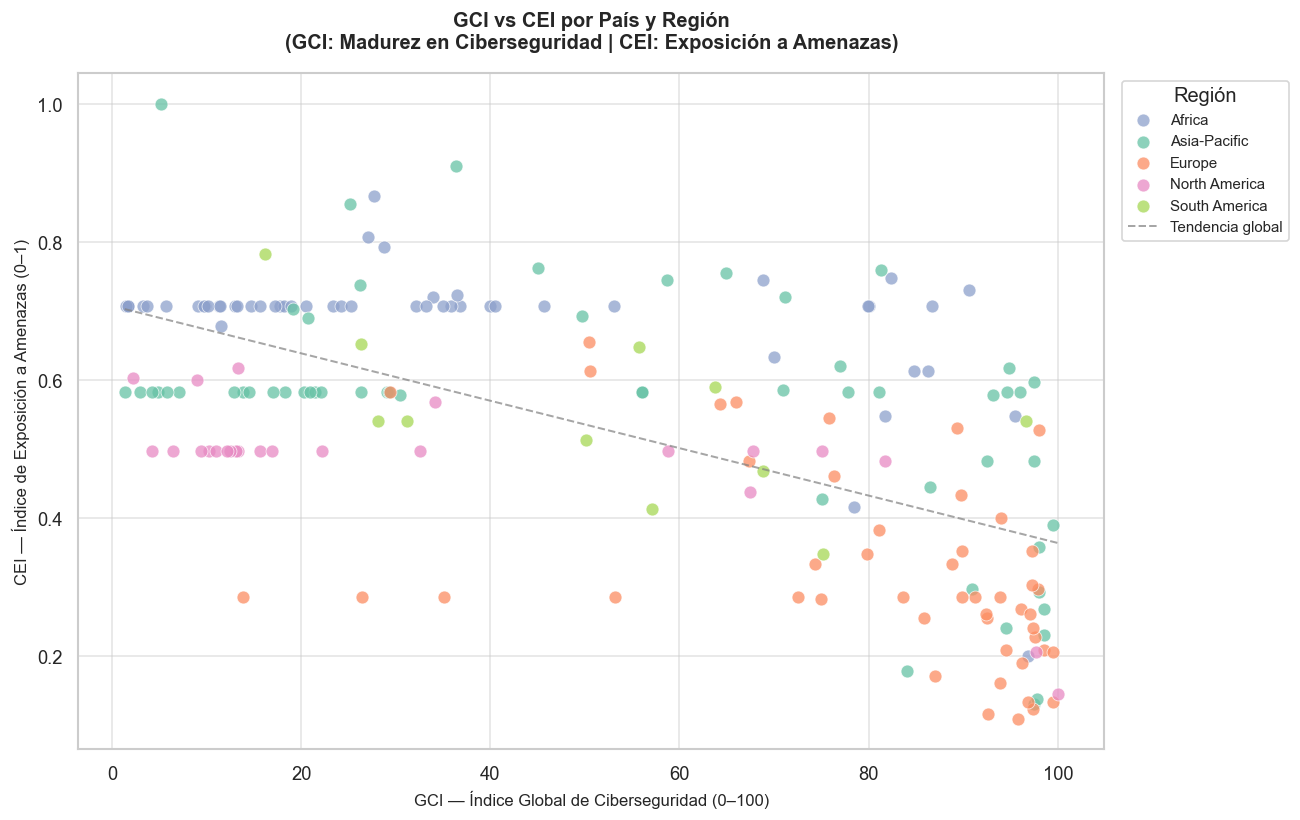

✅ Visualización 2 generada y guardada


In [26]:
# Usar dim_ciberseguridad enriquecida con región desde dim_pais
df_viz2 = dim_ciberseguridad.merge(
    dim_pais[['country', 'region']], on='country', how='left'
)

fig, ax = plt.subplots(figsize=(11, 7))

# Paleta de colores por región
regiones   = df_viz2['region'].dropna().unique()
colores    = sns.color_palette('Set2', len(regiones))
color_map  = dict(zip(regiones, colores))

for region, grupo in df_viz2.groupby('region'):
    ax.scatter(
        grupo['gci'], grupo['cei'],
        label=region,
        color=color_map.get(region, 'gray'),
        alpha=0.75, s=60, edgecolors='white', linewidths=0.5
    )

# Línea de tendencia global (regresión lineal simple con numpy)
x_clean = df_viz2['gci'].dropna()
y_clean = df_viz2.loc[x_clean.index, 'cei'].dropna()
idx     = x_clean.index.intersection(y_clean.index)
if len(idx) > 1:
    z  = np.polyfit(x_clean[idx], y_clean[idx], 1)
    p  = np.poly1d(z)
    xs = np.linspace(x_clean.min(), x_clean.max(), 200)
    ax.plot(xs, p(xs), '--', color='gray', linewidth=1.2,
            alpha=0.7, label='Tendencia global')

ax.set_title('GCI vs CEI por País y Región\n'
             '(GCI: Madurez en Ciberseguridad | CEI: Exposición a Amenazas)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('GCI — Índice Global de Ciberseguridad (0–100)', fontsize=10)
ax.set_ylabel('CEI — Índice de Exposición a Amenazas (0–1)', fontsize=10)
ax.legend(title='Región', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('viz2_gci_vs_cei.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualización 2 generada y guardada')

### Visualización 3 — Distribución de Tipos de Ataque por Nivel de Severidad

**Pregunta**: ¿Qué tipos de ataque son más frecuentes y cómo se distribuyen
sus niveles de severidad?

Se usa un gráfico de barras apiladas que muestra simultáneamente la frecuencia
de cada tipo de ataque y la composición interna por nivel de severidad.
Esto permite identificar qué ataques son frecuentes pero de baja severidad
versus cuáles son infrecuentes pero críticos.

Tipos de ataque únicos: 6
         attack_type  count
0               Ddos    531
1           Phishing    529
2      Sql Injection    503
3         Ransomware    493
4            Malware    485
5  Man-In-The-Middle    459


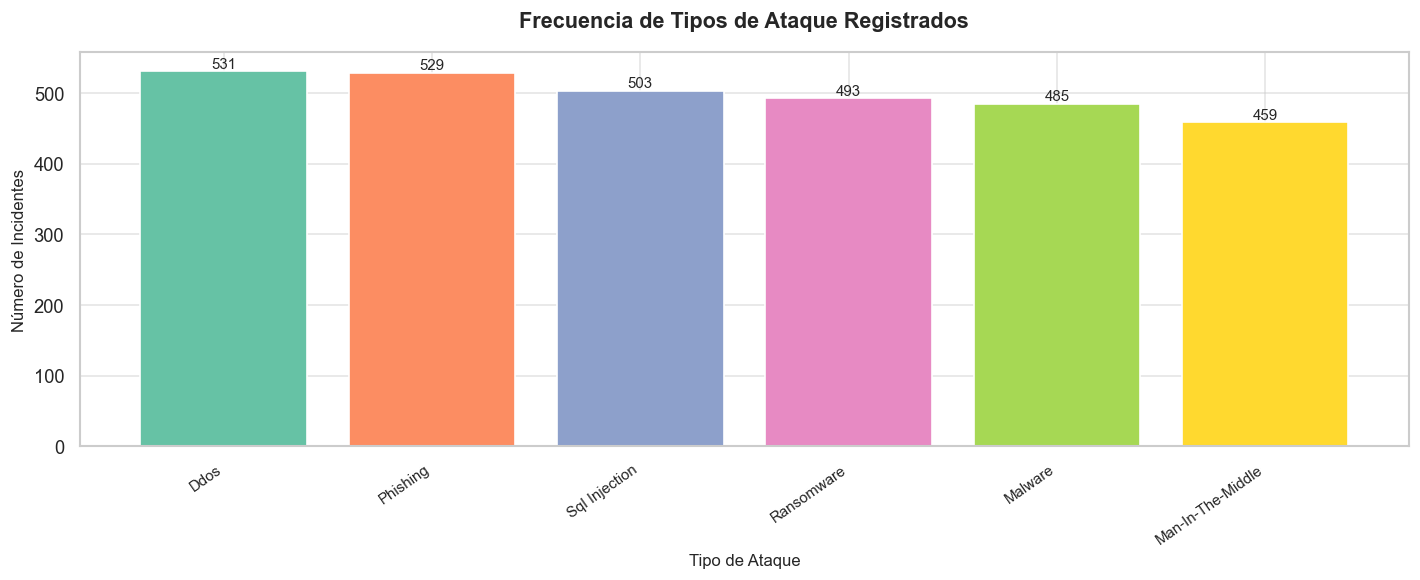

✅ Visualización 3 generada y guardada


In [29]:
# Visualización 3 — Frecuencia de Tipos de Ataque
# Se usa solo attack_type porque severity_level no está disponible en el dataset

df_viz3 = (
    fact_table
    .merge(dim_ataque[['id_ataque', 'attack_type']], on='id_ataque', how='left')
    .dropna(subset=['attack_type'])
    .groupby('attack_type', as_index=False)
    .size()
    .rename(columns={'size': 'count'})
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

print(f'Tipos de ataque únicos: {len(df_viz3)}')
print(df_viz3)

if len(df_viz3) == 0:
    print('❌ df_viz3 está vacío — revisar el merge con dim_ataque')
else:
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.bar(
        df_viz3['attack_type'],
        df_viz3['count'],
        color=sns.color_palette('Set2', len(df_viz3)),
        edgecolor='white'
    )

    for i, val in enumerate(df_viz3['count']):
        ax.text(i, val + 0.3, str(int(val)), ha='center', va='bottom', fontsize=9)

    ax.set_title('Frecuencia de Tipos de Ataque Registrados',
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Tipo de Ataque', fontsize=10)
    ax.set_ylabel('Número de Incidentes', fontsize=10)
    plt.xticks(rotation=35, ha='right', fontsize=9)
    plt.tight_layout()
    plt.savefig('viz3_frecuencia_ataques.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✅ Visualización 3 generada y guardada')

# Carga del Modelo de Estrella a AWS (target final)


In [43]:
import os
import boto3
from dotenv import load_dotenv
import redshift_connector

load_dotenv()

True

In [46]:
load_dotenv()
client = boto3.client(
    's3',
    aws_access_key_id=os.getenv('AWS_KEY_ID'),
    aws_secret_access_key=os.getenv('AWS_KEY')
)
conn = redshift_connector.connect(
    host=os.getenv('AWS_HOST'),
    database=os.getenv('AWS_DB'),
    port=5439,
    user=os.getenv('AWS_USR'),
    password=os.getenv('AWS_PASS')
)


cursor = conn.cursor()

## Generación de la Carga de datos a AWS

### Función de carga del modelo


In [70]:
def load_file(file_name, table_name, bucket='inteligencianeg'):
    """
    Carga un archivo CSV desde local a S3 y luego a Redshift
    ✅ DELIMITADOR: COMA (,)
    """
    try:
        # Paso 1: Subir a S3
        print(f"\n📤 Subiendo {file_name} a S3...")
        s3_client.upload_file(
            Filename=f"data/{file_name}",
            Bucket=bucket,
            Key=f"etl_t/{file_name}",
        )
        print(f"   ✅ Archivo en S3")

        # Paso 2: COPY en Redshift (DELIMITADOR COMA)
        print(f"📥 Cargando en tabla {table_name}...")

        copy_sql = f'''
        COPY public.{table_name}
        FROM 's3://{bucket}/etl_t/{file_name}'
        CREDENTIALS 'aws_access_key_id={os.getenv("AWS_KEY_ID")};aws_secret_access_key={os.getenv("AWS_KEY")}'
        CSV
        DELIMITER ','
        REGION 'us-east-2'
        IGNOREHEADER 1
        '''

        cursor.execute(copy_sql)
        conn.commit()

        # Paso 3: Verificar
        cursor.execute(f"SELECT COUNT(*) FROM public.{table_name};")
        count = cursor.fetchone()[0]

        print(f"   ✅ {count} registros cargados")
        return True

    except Exception as e:
        conn.rollback()
        print(f"   ❌ Error: {str(e)[:150]}")
        return False

In [71]:
load_file('Cyber_security.csv','Cyber_security')


📤 Subiendo Cyber_security.csv a S3...
   ✅ Archivo en S3
📥 Cargando en tabla Cyber_security...
   ✅ 192 registros cargados


True

In [73]:
load_file('Global_Cybersecurity_Threats.csv','Global_Cybersecurity_Threats')


📤 Subiendo Global_Cybersecurity_Threats.csv a S3...
   ✅ Archivo en S3
📥 Cargando en tabla Global_Cybersecurity_Threats...
   ✅ 3000 registros cargados


True

In [74]:
load_file('internet_users_by_country_cleaned.csv','internet_users_by_country_cleaned')


📤 Subiendo internet_users_by_country_cleaned.csv a S3...
   ✅ Archivo en S3
📥 Cargando en tabla internet_users_by_country_cleaned...
   ✅ 215 registros cargados


True

---
## REFLEXIÓN INDIVIDUAL FINAL
## Aplicación Profesional - Juan Diego Guevara
En mi entorno laboral, relacionado con infraestructura tecnológica y ciberseguridad en la Bolsa de Valores de Quito, este proceso de carga podría aplicarse para centralizar información proveniente de diferentes plataformas como Microsoft 365, Fortinet, Bitdefender, Azure, Active Directory y herramientas de monitoreo. Mediante un modelo de datos estructurado en dimensiones y hechos sería posible consolidar eventos de seguridad, incidentes, accesos de usuarios y métricas operativas en un repositorio centralizado para análisis histórico.
La implementación de un proceso ETL permitiría automatizar la extracción, transformación y carga de datos, garantizando información consistente y confiable para la generación de indicadores de gestión y ciberseguridad. Esto facilitaría la identificación de tendencias, vulnerabilidades recurrentes, tiempos de respuesta ante incidentes y riesgos operativos. Asimismo, el uso de plataformas en la nube como Amazon S3 y Redshift permitiría almacenar grandes volúmenes de información y realizar consultas analíticas de forma eficiente, apoyando la toma de decisiones estratégicas y fortaleciendo la gestión de seguridad de la información dentro de la organización.
## Jeremy Moreno
*Oficial de Seguridad de Datos e Información — Institución Financiera*

---

En mi rol como oficial de seguridad de datos en una institución financiera, el proceso
que más tiempo consume hoy es la consolidación manual de alertas del DLP para presentar
reportes de incidentes a la dirección. Los datos están disponibles pero dispersos,
sin estructura analítica.

Lo que implementaría con este proceso de carga es precisamente eso: un modelo de estrella
donde la tabla de hechos contenga cada alerta del DLP como un registro, con claves
foráneas hacia dimensiones de usuario, tipo de dato afectado, política violada y canal
de fuga (email, USB, nube). Esto me permitiría consultar directamente en Redshift,
por ejemplo, cuántas alertas de exfiltración por email tuvo el área de operaciones
en el último trimestre, sin procesar manualmente los logs cada vez.

De forma separada, haría lo mismo con los logs de Entra ID: un modelo estrella donde
cada evento de autenticación o cambio de permisos sea un hecho, con dimensiones de
usuario, dispositivo, ubicación y hora. Cargado en Redshift, podría automatizar
consultas semanales para detectar escaladas de privilegios no autorizadas o accesos
desde ubicaciones inusuales, convirtiendo un proceso hoy reactivo en uno proactivo
y basado en datos históricos estructurados.